### Proje için gereken kütüphaneleri import etme

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt

### Veri setini yükleme / EDA (Keşifçi Veri Analizi)

In [2]:
df = pd.read_csv("ab_test_data.csv") # csv formatını Pandas DataFrame'ine (satır ve sütunlardan) oluşan 2 boyutlu yapıya dönüştürme.

In [3]:
print(f"Veri setimizin gözlem (satır) sayısı: {df.shape[0]}")
print(f"Veri setimizin sütun sayısı: {df.shape[1]}")

Veri setimizin gözlem (satır) sayısı: 1000
Veri setimizin sütun sayısı: 7


In [4]:
print(f"Veri seti hakkındaki genel bilgi: {df.info()}") # veri setinin sütun tiplerini bellekte ne kadar yer kapladığına bakıyoruz. 

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  1000 non-null   str    
 1   group        1000 non-null   str    
 2   age          970 non-null    float64
 3   gender       1000 non-null   str    
 4   clicked      980 non-null    float64
 5   purchased    1000 non-null   int64  
 6   revenue      1000 non-null   float64
dtypes: float64(3), int64(1), str(3)
memory usage: 54.8 KB
Veri seti hakkındaki genel bilgi: None


In [5]:
print(df.describe()) # sayısal sütunlar üzerindeki betimleyici istatistiksel bilgilere erişelim.

              age     clicked    purchased     revenue
count  970.000000  980.000000  1000.000000  1000.00000
mean    41.371134    0.400000     0.325000   233.44688
std     13.735313    0.490148     0.468609   148.34178
min     18.000000    0.000000     0.000000    -1.00000
25%     29.000000    0.000000     0.000000   104.62000
50%     42.000000    0.000000     0.000000   224.99500
75%     53.000000    1.000000     1.000000   364.91750
max     64.000000    1.000000     1.000000   498.81000


In [6]:
print(f"Boş hücre kontrolü:\n{df.isnull().sum()}")

Boş hücre kontrolü:
customer_id     0
group           0
age            30
gender          0
clicked        20
purchased       0
revenue         0
dtype: int64


In [7]:
print(df.head())

  customer_id group   age  gender  clicked  purchased  revenue
0       C0001     A   NaN    Male      0.0          1    99.92
1       C0002     B  26.0  Female      0.0          0    27.76
2       C0003     A  50.0    Male      1.0          0   284.23
3       C0004     A  37.0  Female      0.0          0   325.76
4       C0005     A  30.0  Female      1.0          0   105.39


### EDA Sonuç
* Veri setimiz 1000 satır ve 7 sütundan oluşuyor.
* Veri setindeki sütunlarımız

- customer_id → müşteri kimlik numarası
- group → A: eski kampanya, B: yeni kampanya
- age → müşterinin yaşı
- gender → müşterinin cinsiyeti
- clicked → e-postadaki linke tıkladı mı? 1: evet, 0: hayır
- purchased → satın aldı mı? 1: evet, 0: hayır
- revenue → elde edilen gelir

* Veri setimizde age sütununda 30 clicked sütununda 20 boş hücre var. 
* Veri setimizde revenue sütununda min değer -1. Bu da bu verilerin hatalı olduğunu gösterir. Bu gözlemleri veri setinden çıkaracağız.


### Veri Temizleme ve Feature Engineering

In [8]:
cleaned_df = df[df["revenue"]>=0] # revenue sütunundaki yanlış verileri temizliyoruz.
print(f"Temizlenmiş veri setinin satır boyutu: {cleaned_df.shape[0]}")

Temizlenmiş veri setinin satır boyutu: 975


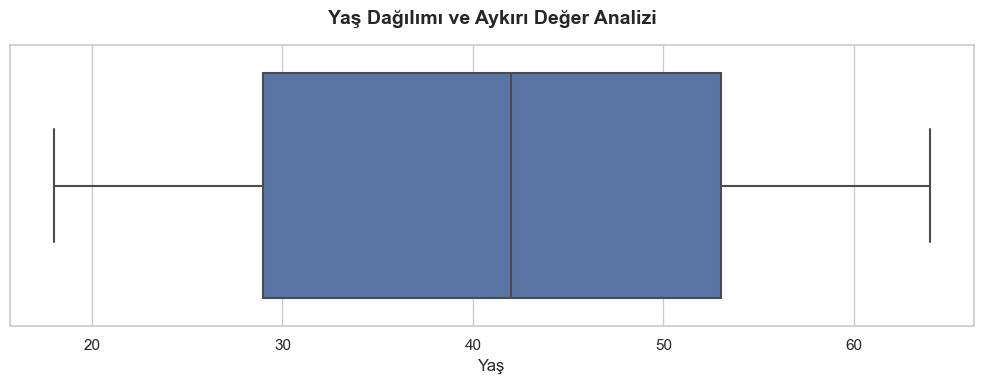

In [9]:
# age sütununda outlier değer var mı ? Eğer bu sütunda outlier değer varsa boş hücreleri outliere dayanıklı olan medyan ile aksi takdirde boş hücreleri outliere duyarlı olan ortalama ile dolduracağız.
# 1. Grafik boyutunu ve arka plan temasını ayarlıyoruz.
plt.figure(figsize=(10, 4))
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=cleaned_df,
    x="age",
    color="#4C72B0",    
    fliersize=5,           # Aykırı değer (outlier) noktalarının boyutu
    linewidth=1.5,         # Kutu çizgilerinin kalınlığı
)

# 3. Grafik başlığı ve eksen isimlerini belirleyelim.
plt.title("Yaş Dağılımı ve Aykırı Değer Analizi", fontsize=14, pad=15, fontweight="bold")
plt.xlabel("Yaş", fontsize=12)

# 4. Grafiği temiz bir şekilde ekrana basın
plt.tight_layout()
plt.show()


In [10]:
# grafikten de anlaşılacağı üzere age sütununda outlier (uçdeğer) yok bu durumda bu sütundaki boş hücreleri ortalama ile dolduracağız.
yas_ortalamasi = cleaned_df["age"].mean()
cleaned_df["age"] = cleaned_df["age"].fillna(yas_ortalamasi)
# clicked sütunu 1-0 şeklinde kategorik bir sütun olduğu için bu sütuna ait boş hücreleri ilgili sütunun mod değeriyle dolduracağız.
clicked_mod = cleaned_df["clicked"].mode()[0]
cleaned_df["clicked"] = cleaned_df["clicked"].fillna(clicked_mod)
# veri setimizde boş hücre kaldı mı kontrol edelim
print(cleaned_df.isnull().sum()[cleaned_df.isnull().sum() > 0])


Series([], dtype: int64)


In [11]:
print(f"Veri setimizin ilk 10 satırı:\n {cleaned_df.head(n=10)}")

Veri setimizin ilk 10 satırı:
   customer_id group       age  gender  clicked  purchased  revenue
0       C0001     A  41.34709    Male      0.0          1    99.92
1       C0002     B  26.00000  Female      0.0          0    27.76
2       C0003     A  50.00000    Male      1.0          0   284.23
3       C0004     A  37.00000  Female      0.0          0   325.76
4       C0005     A  30.00000  Female      1.0          0   105.39
5       C0006     B  45.00000    Male      0.0          1   278.23
6       C0007     A  46.00000  Female      0.0          1   428.25
7       C0008     A  30.00000  Female      0.0          1   417.53
8       C0009     A  63.00000    Male      1.0          1   463.68
9       C0010     B  52.00000  Female      0.0          0   182.94


In [21]:
tiklanma_oranlari = cleaned_df.groupby("group").agg(tiklanma_oranlari = ("clicked", "mean")).reset_index(False)
print(tiklanma_oranlari)

  group  tiklanma_oranlari
0     A           0.373166
1     B           0.401606


In [22]:
satin_alma_oranlari = cleaned_df.groupby("group").agg(satin_alma_oranlari = ("purchased", "mean")).reset_index(False)
print(satin_alma_oranlari)

  group  satin_alma_oranlari
0     A             0.329140
1     B             0.329317


### İstatistiksel Analizler

In [13]:
# A ve B grubundaki tıklanma oranları arasındaki farkın tesadüf mü yoksa gerçekten anlamlı olduğunu belirlemek için ki-kare testi yapacağız.
# Ki-Kare iki kategorik değişken arasındaki ilişkiyi ölçer. Analiz sonucu çıkan p değeri <0.05 ise bu iki değişken arasında anlamlı bir ilişki vardır deriz.
from scipy.stats import chi2_contingency # scipy kütüphanesinin stats modülünden ki-kare fonksiyonunu import ediyoruz.
contingency_table = pd.crosstab(cleaned_df["group"], cleaned_df["clicked"])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square istatistiği: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")

Chi-square istatistiği: 0.7147
P-value: 0.3979


In [14]:
contingency_table1 = pd.crosstab(cleaned_df["group"], cleaned_df["purchased"])
chi2, p_value, dof, expected = chi2_contingency(contingency_table1)
print(f"Chi-square istatistiği: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")

Chi-square istatistiği: 0.0000
P-value: 1.0000


In [15]:
from scipy.stats import ttest_ind

group_a = cleaned_df[cleaned_df["group"] == "A"]["revenue"]
group_b = cleaned_df[cleaned_df["group"] == "B"]["revenue"]

t_stat, p_value = ttest_ind(group_a, group_b)

print(f"T-istatistiği: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

T-istatistiği: 0.9103
P-value: 0.3629


In [29]:
# veriyi görselleştirmeden önce satın alma oranlarını yüzdesel olacak şekilde 2 basamağa yuvarlanmış forma getirelim.
satin_alma_oranlari["satin_alma_oranlari"] = satin_alma_oranlari["satin_alma_oranlari"] * 100
satin_alma_oranlari = satin_alma_oranlari.sort_values(by="satin_alma_oranlari", ascending=False)
print(satin_alma_oranlari.head())
# veriyi görselleştirmeden önce tıklanma oranlarını yüzdesel olacak şekilde 2 basamağa yuvarlanmış forma getirelim.
tiklanma_oranlari["tiklanma_oranlari"] = tiklanma_oranlari["tiklanma_oranlari"] * 100
tiklanma_oranlari = tiklanma_oranlari.sort_values(by="tiklanma_oranlari", ascending=False)
tiklanma_oranlari.head()

  group  satin_alma_oranlari
1     B         3.293173e+07
0     A         3.291405e+07


,group,tiklanma_oranlari
1,B,4016.064257
0,A,3731.656184


### Veri Görselleştirme

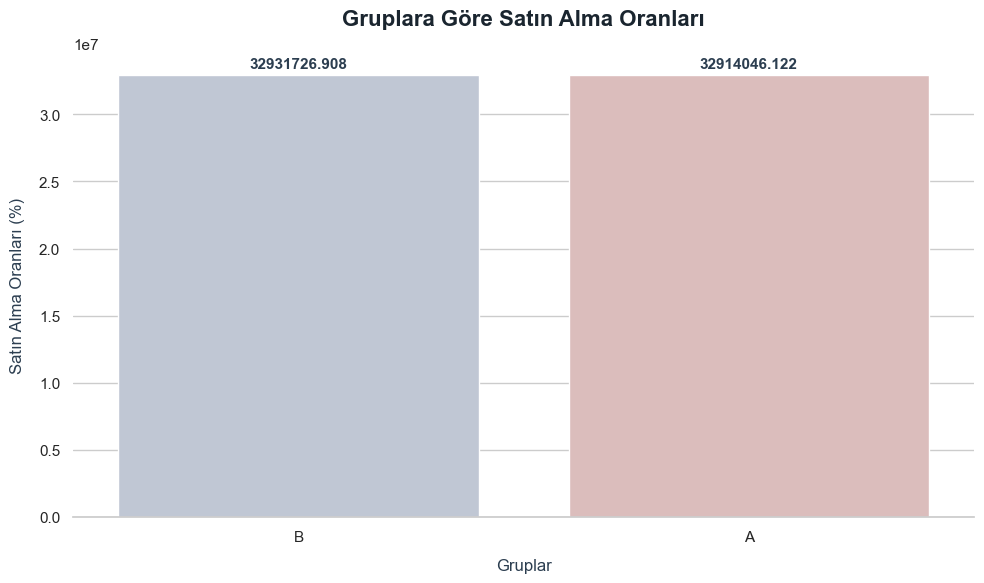

In [31]:
# 1. Modern bir tema seçimi (Arka plan beyaz/ızgaralı)
sns.set_theme(style="whitegrid", rc={"text.color": "#2c3e50", "axes.labelcolor": "#2c3e50"})

# 2. Grafik boyutunu ayarlama
plt.figure(figsize=(10, 6), dpi=100)

# 3. Bar grafik çizimi (Yumuşak ve uyumlu bir renk paleti: "muted" veya "viridis")
ax = sns.barplot(
    x="group",
    y="satin_alma_oranlari",
    data=satin_alma_oranlari,
    palette="vlag",  # Şık renk geçişleri için 'vlag', 'coolwarm' veya 'Blues_r' denenebilir
    hue="group",  # Yeni Seaborn sürümleri için hue tanımı ve efsane kapatma
    legend=False,
)

# 4. Grafik başlığı ve eksen isimlerini özelleştirme
plt.title(
    "Gruplara Göre Satın Alma Oranları",
    fontsize=16,
    fontweight="bold",
    pad=20,
    color="#1a252f",
)
plt.xlabel("Gruplar", fontsize=12, labelpad=10)
plt.ylabel("Satın Alma Oranları (%)", fontsize=12, labelpad=10)

# 5. Eksen çizgilerini ve font boyutlarını düzenleme
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# 6. Barların üzerine değerlerini (etiketlerini) ekleme
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f", # %.2f virgülden sonra 2 basamak alır, %% ise '%' işareti koyar
        padding=3,
        fontsize=11,
        fontweight="bold",
        color="#2c3e50",
    )

# 7. Üst ve sağdaki gereksiz çerçeve çizgilerini kaldırma
sns.despine(left=True, bottom=False)

# Grafiği sıkıştırıp ekrana verme
plt.tight_layout()
plt.show()


In [21]:
tiklanma_oranlari.head()

,tiklanma_oranlari
group,
A,0.373166
B,0.401606


### SONUÇ

* Müşterileri gruplarına göre ayırıp tıklanma oranları arasındaki ilişki incelendiğinde müşterilerin grupları arasında tıklanma yönünden anlamlı bir farklılık tespit edilmemiştir (p=0.40)
* Müşterileri gruplarına göre ayırıp satın alma oranları arasındaki ilişki incelendiğinde müşterilerin grupları arasında satın alma yönünden anlamlı bir farklılık tespit edilmemiştir (p=1.00). İki grup arasında sıfır fark var yani A ve B grubu satın alma oranları neredeyse aynı.
* Müşterileri gruplarına göre ayırıp harcadıkları gelir bakımından anlamlı bir farklılıp olup olmadığına dair yapılan bağımsız örneklem t testi sonuçlarına göre müşterilerin grupları arasında harcadıkları para bakımından anlamlı bir farklılık tespit edilmemiştir (p=0.36)
* Sonuç olarak, yapılan analizlerden yola çıkarak A ve B kampanyaları arasında neredeyse hiçbir farklılık olmadığını söyleyebiliriz. Bu durumda satın alma oranları ve tıklanma oranları da incelendiğinde B kampanyasını sürdürüp A kampanyasının iptal edilmesi yerinde bir karar olacaktır ancak daha kesin bir sonuç için daha büyük örneklemle analizlerin tekrarlanması yerinde olacaktır.